# EDA

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score

In [28]:
df = pd.read_csv('winequality-white.csv')
df.head()
df.shape

(4898, 12)

In [29]:
duplicate = df.duplicated()
print(duplicate.sum())
df[duplicate]

937


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.900000,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.100000,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.800000,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.500000,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.98920,3.33,0.39,12.800000,8
...,...,...,...,...,...,...,...,...,...,...,...,...
4828,6.4,0.23,0.35,10.3,0.042,54.0,140.0,0.99670,3.23,0.47,9.200000,5
4850,7.0,0.36,0.35,2.5,0.048,67.0,161.0,0.99146,3.05,0.56,11.100000,6
4851,6.4,0.33,0.44,8.9,0.055,52.0,164.0,0.99488,3.10,0.48,9.600000,5
4856,7.1,0.23,0.39,13.7,0.058,26.0,172.0,0.99755,2.90,0.46,9.000000,6


In [30]:
df.quality.value_counts()
df.shape

(4898, 12)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [32]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

C:\Users\baohu\AppData\Local\Temp\ipykernel_5772\3181396357.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = class_counts.index, y = class_counts.values, palette='viridis')


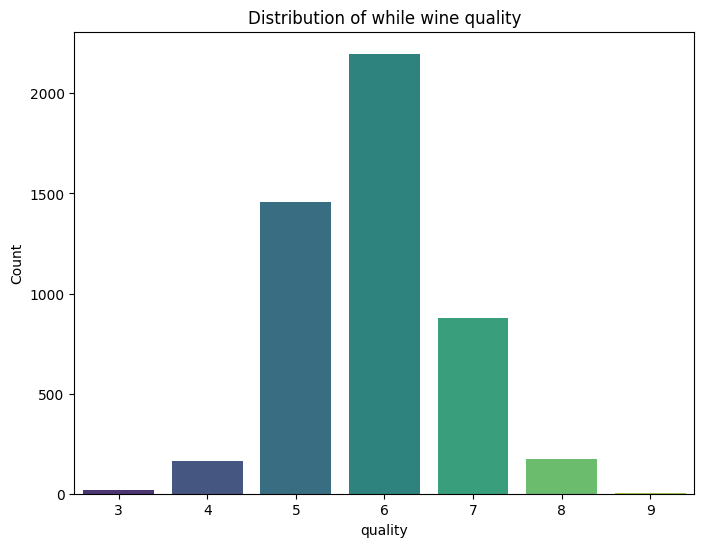

Class distribution
quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64


In [33]:
class_counts = df['quality'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x = class_counts.index, y = class_counts.values, palette='viridis')
plt.title('Distribution of while wine quality')
plt.ylabel('Count')
plt.show()

print("Class distribution")
print(class_counts)

C:\Users\baohu\AppData\Local\Temp\ipykernel_5772\2977247297.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='quality', y = 'alcohol', data=df, palette='inferno')


<Axes: xlabel='quality', ylabel='alcohol'>

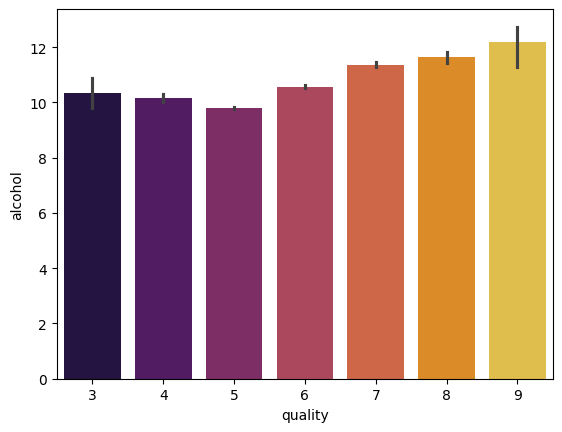

In [9]:
sns.barplot(x='quality', y = 'alcohol', data=df, palette='inferno')

<Axes: xlabel='quality', ylabel='alcohol'>

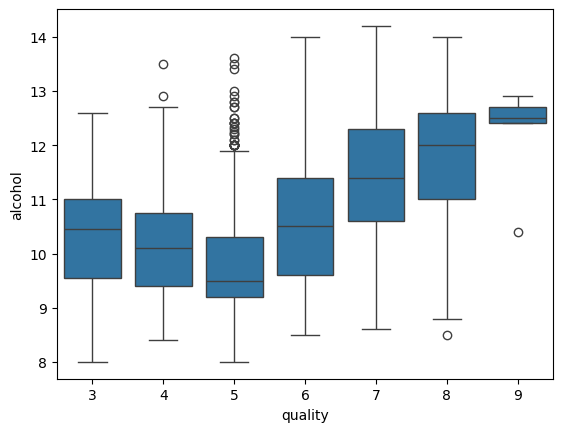

In [10]:
sns.boxplot(x='quality', y='alcohol', data=df)

In [ ]:
columns = list(df.columns)
fig, ax = plt.subplots(11, 2, figsize=(15, 45))
plt.subplots_adjust(hspace = 0.5)
for i in range(11) :
    # AX 1
    sns.boxplot(x=columns[i], data=df, ax=ax[i, 0])
    # Ax 2
    sns.scatterplot(x=columns[i], y='quality', data=df, hue='quality', ax=ax[i, 1])

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

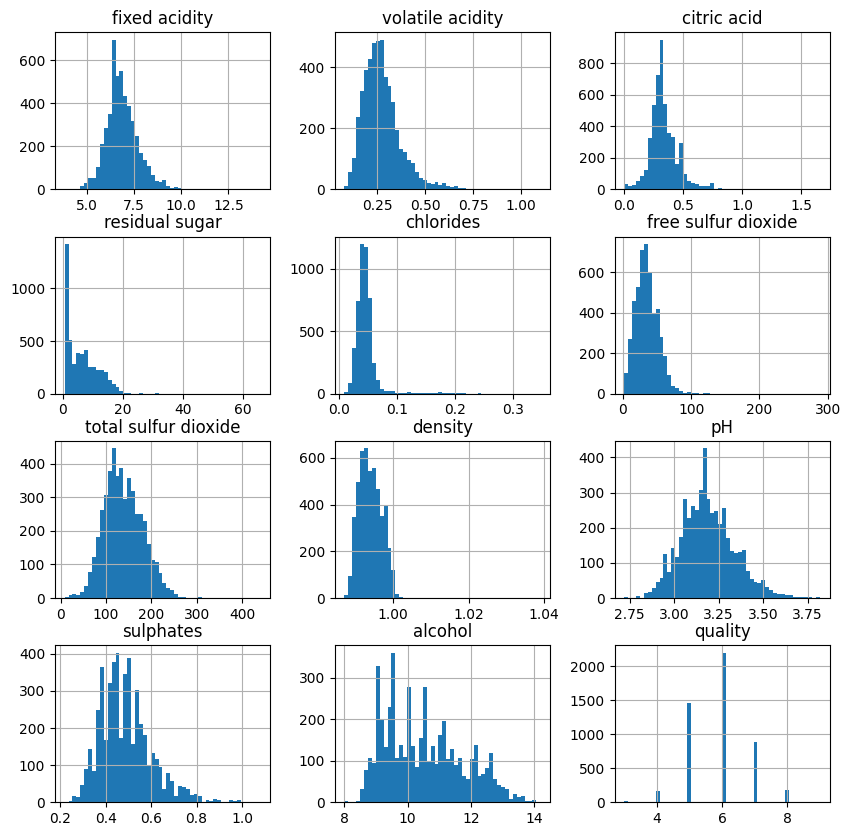

In [12]:
df.hist(figsize=(10, 10), bins=50)

<Axes: >

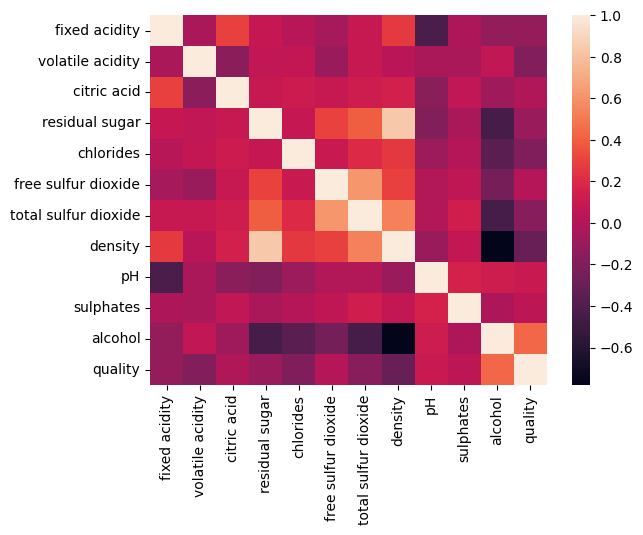

In [13]:
sns.heatmap(df.corr())

# OverSampling for all quality


In [34]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

In [44]:
train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [46]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

In [47]:
# Display the class counts after oversampling
class_counts2 = pd.Series(y_resampled).value_counts()
print(class_counts2)

quality
6    1766
5    1766
7    1766
3    1766
4    1766
8    1766
9    1766
Name: count, dtype: int64


In [56]:
rf_classifier = RandomForestClassifier()

# Train the Random Forest model
rf_classifier.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
rf_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(rf_acc * 100))

Precision: 0.19586417414409937
Recall: 0.2510204081632653
F1-score: 0.2189021020976429
Accuracy: 25.10%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [55]:
et_classifier = ExtraTreesClassifier(n_estimators=200, random_state=42)

# Train the Extra Trees model
et_classifier.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = et_classifier.predict(X_test)

# Evaluate the model
et_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(et_acc * 100))

Precision: 0.16722981338129123
Recall: 0.04897959183673469
F1-score: 0.07083499254405129
Accuracy: 4.90%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [57]:
dt_classifier = DecisionTreeClassifier()

ba = BaggingClassifier(dt_classifier, n_estimators=100, random_state=42)

# Train the Decision model
ba.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = ba.predict(X_test)

# Evaluate the model
dt_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(dt_acc * 100))

Precision: 0.038384006663890045
Recall: 0.19591836734693877
F1-score: 0.0641916834993383
Accuracy: 19.59%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [58]:
KNN = KNeighborsClassifier()

# Train the KNN model
KNN.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = KNN.predict(X_test)

# Evaluate the model
knn_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(knn_acc * 100))

Precision: 2.603082049146189e-05
Recall: 0.00510204081632653
F1-score: 5.179736869367036e-05
Accuracy: 0.51%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [59]:
lr = LogisticRegression()

# Train the LR model
lr.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = lr.predict(X_test)

# Evaluate the model
lr_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(lr_acc * 100))

Precision: 0.0
Recall: 0.0
F1-score: 0.0
Accuracy: 0.00%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedM

In [60]:
gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=1,
                                 random_state=42,
                                 max_features=5 )

# Train the glb model
gbc.fit(X_resampled, y_resampled)

# Predictions on the test set
y_pred = gbc.predict(X_test)

# Evaluate the model
gbc_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(gbc_acc * 100))

Precision: 0.12867898913951545
Recall: 0.29081632653061223
F1-score: 0.15189913744388656
Accuracy: 29.08%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [62]:
models1 = pd.DataFrame({
    'Model' : ['RF', 'ET', 'DT',  'KNN', 'LR','GBC'],
    'Score' : [rf_acc, et_acc, dt_acc, knn_acc, lr_acc, gbc_acc]
})


models1.sort_values(by = 'Score', ascending = True)

,Model,Score
4,LR,0.000000
3,KNN,0.005102
1,ET,0.048980
2,DT,0.195918
0,RF,0.251020
5,GBC,0.290816


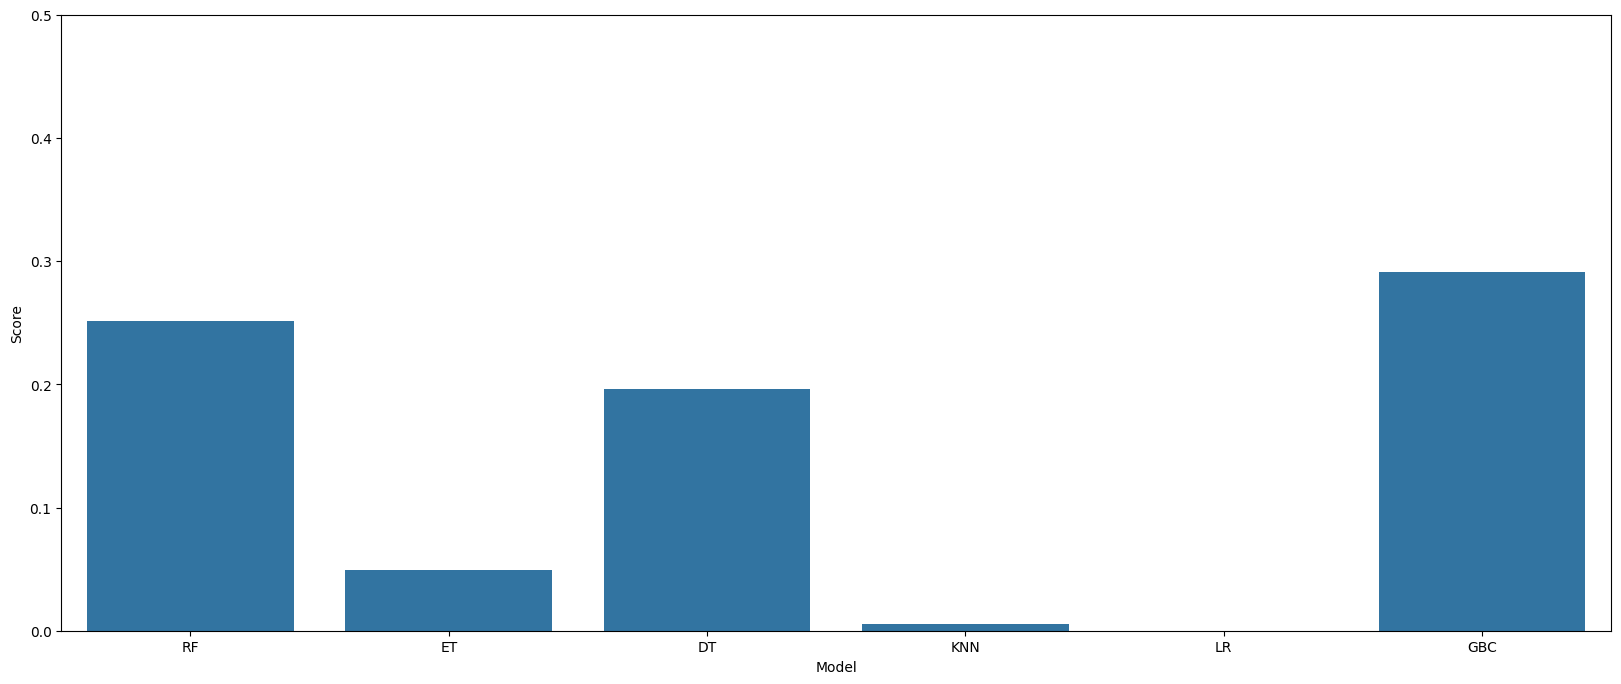

In [65]:
plt.figure(figsize = (20, 8))

sns.barplot(x = 'Model', y = 'Score', data = models1)
plt.ylim(0.0, 0.5)
plt.show()

# Under sampling for Quality 5, 6, 7 and remove 3, 4, 8 ,9

In [66]:
values_to_remove = [3, 9, 4, 8] # loại bỏ các loại rượu 
df1 = df[~df['quality'].isin(values_to_remove)]

In [68]:
X1 = df1.iloc[:, :-1]

y1 = df1.iloc[:, -1]

In [69]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42, shuffle=True)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train1)
X_test = scaler.transform(X_test1)

In [70]:
rus = RandomUnderSampler(random_state=42)
X_resampled1, y_resampled1 = ros.fit_resample(X_train1, y_train1)

In [71]:
# Display the class counts after oversampling
class_counts3 = pd.Series(y_resampled1).value_counts()
print(class_counts3)

quality
5    1789
6    1789
7    1789
Name: count, dtype: int64


In [76]:
rf_classifier = RandomForestClassifier()

# Train the Random Forest model
rf_classifier.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = rf_classifier.predict(X_test1)

# Evaluate the model
rf_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(rf_acc * 100))

Precision: 0.7096483896437125
Recall: 0.7034178610804851
F1-score: 0.7036262171164123
Accuracy: 70.34%


In [77]:
et_classifier = ExtraTreesClassifier(n_estimators=200, random_state=42)

# Train the Extra Trees model
et_classifier.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = et_classifier.predict(X_test1)

# Evaluate the model
et_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(et_acc * 100))

Precision: 0.7623757790968111
Recall: 0.7364939360529217
F1-score: 0.7342227682880943
Accuracy: 73.65%


In [78]:
dt_classifier = DecisionTreeClassifier()

ba = BaggingClassifier(dt_classifier, n_estimators=100, random_state=42)

# Train the Decision model
ba.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = ba.predict(X_test1)

# Evaluate the model
dt_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(dt_acc * 100))

Precision: 0.7118769514673711
Recall: 0.7078280044101434
F1-score: 0.7079546201483188
Accuracy: 70.78%


In [79]:
KNN = KNeighborsClassifier()

# Train the KNN model
KNN.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = KNN.predict(X_test1)

# Evaluate the model
knn_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(knn_acc * 100))

Precision: 0.5374534677219075
Recall: 0.5214994487320838
F1-score: 0.5222283776330239
Accuracy: 52.15%


In [80]:
lr = LogisticRegression()

# Train the LR model
lr.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = lr.predict(X_test1)

# Evaluate the model
lr_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(lr_acc * 100))

Precision: 0.5114329215242976
Recall: 0.48511576626240355
F1-score: 0.4567789604563511
Accuracy: 48.51%


c:\Users\baohu\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [81]:
gbc = GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=1,
                                 random_state=42,
                                 max_features=5 )

# Train the glb model
gbc.fit(X_resampled1, y_resampled1)

# Predictions on the test set
y_pred = gbc.predict(X_test1)

# Evaluate the model
gbc_acc = accuracy_score(y_test1, y_pred)
precision = precision_score(y_test1, y_pred, average='weighted')
recall = recall_score(y_test1, y_pred, average='weighted')
f1 = f1_score(y_test1, y_pred, average='weighted')

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-score: {f1}')
print("Accuracy: {:.2f}%".format(gbc_acc * 100))

Precision: 0.6989321077225908
Recall: 0.6957001102535832
F1-score: 0.6962280918045298
Accuracy: 69.57%


In [82]:
models2 = pd.DataFrame({
    'Model' : ['RF', 'ET', 'DT',  'KNN', 'LR','GBC'],
    'Score' : [rf_acc, et_acc, dt_acc, knn_acc, lr_acc, gbc_acc]
})


models2.sort_values(by = 'Score', ascending = True)

,Model,Score
4,LR,0.485116
3,KNN,0.521499
5,GBC,0.695700
0,RF,0.703418
2,DT,0.707828
1,ET,0.736494


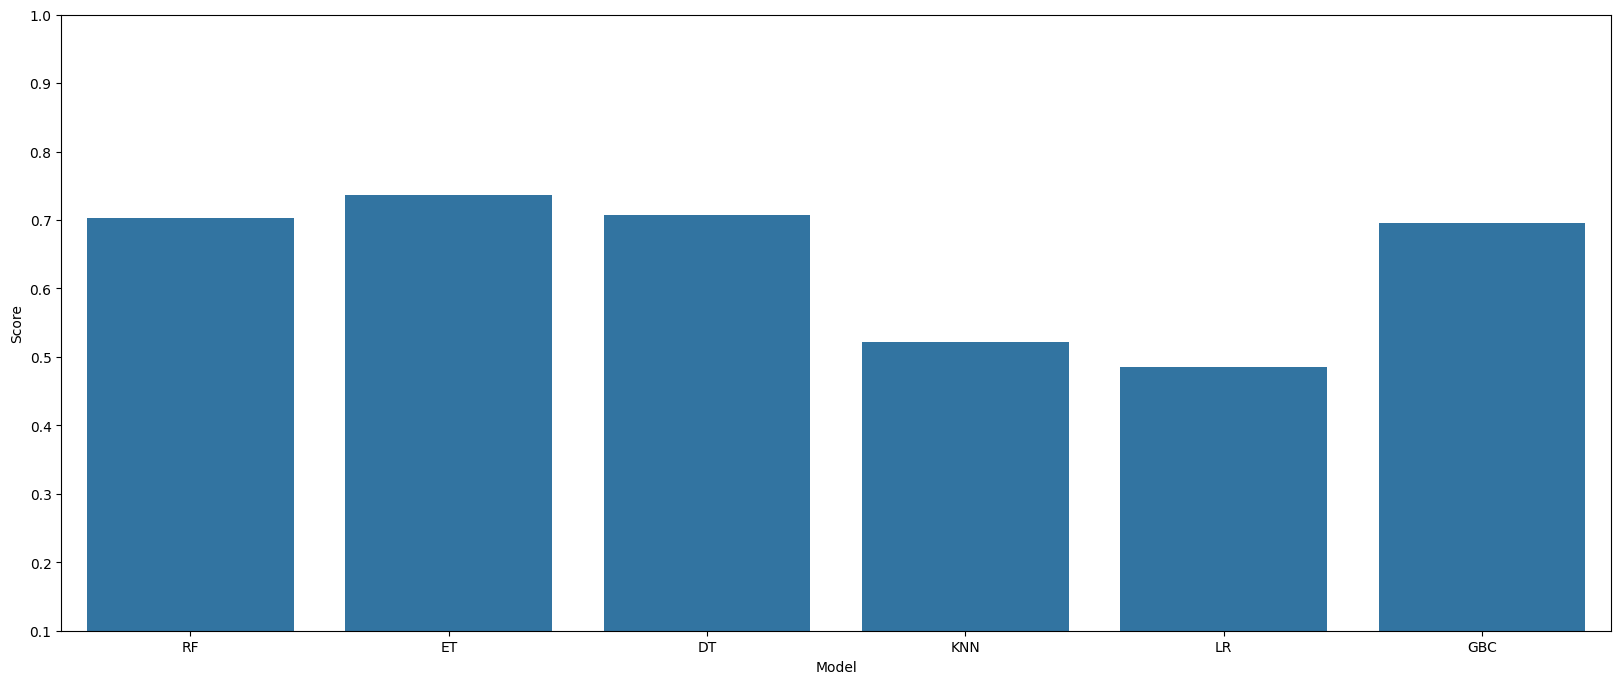

In [84]:
plt.figure(figsize = (20, 8))

sns.barplot(x = 'Model', y = 'Score', data = models2)
plt.ylim(0.1, 1)
plt.show()